# TensorBinding.jl — Many-Body Methods

Methods for correlated and interacting systems:

1. **Exciton Hamiltonians** — two-particle electron-hole systems encoded
   in a `2L`-qubit chain; LDoS and DoS via MPS-mode KPM.
2. **RPA susceptibility** — Dyson series resummed via the Wynn
   epsilon-algorithm.


In [16]:
using LinearAlgebra
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl")
using .TensorBinding

---
## 1. Exciton Hamiltonians

An exciton is a correlated electron-hole pair.  In the quantics representation
the two-particle Hilbert space is encoded on a `2L`-qubit chain:
odd sites for the electron position qubits and even sites for the hole position qubits.

The exciton Hamiltonian is
$$H_{\rm exc} = H_e \otimes I_h + I_e \otimes H_h + V_{eh}$$
where $V_{eh}(r_e, r_h) = -U(r,r)$ is a Hubbard-type interaction that can be modulated in space.

The `2L`-site MPO makes the standard MPO-mode Chebyshev list expensive;
the **MPS mode** (`KPM_Tn(H, Ncheb, X; ...)`) propagates a single reference
state $|X, X\rangle$ and is the recommended approach.

In [18]:
# 1D electron + hole on a chain; APSOS-style modulated type-I confinement
L_exc      = 5          # 2^5 = 32 sites per particle
t_exc      = -1.0
U_exc      = 6.0        # contact attraction strength
V0_exc     = 1.5        # confinement scale
scale_exc  = 10.0
maxdim_exc = 100

N_sites_exc = 2^L_exc

function Vx_exc(x; V0=V0_exc, N=N_sites_exc)

    b = sqrt(3)*N/10
    k = 2*pi/b

    return V0*(1 + 0.2*(cos(k*x)))
end

H_exc = TensorBinding.exciton_hamiltonian("chain_1d", t_exc, x -> U_exc;
    L       = L_exc,
    on_site = Vx_exc,
    scale   = scale_exc,
    maxdim  = maxdim_exc)
println(H_exc)

TBHamiltonian | L=5, N=32 [exciton, D=1024], scale=10.0, maxlinkdim=11 | geometry: 32 sites, 1D | no Tn cache


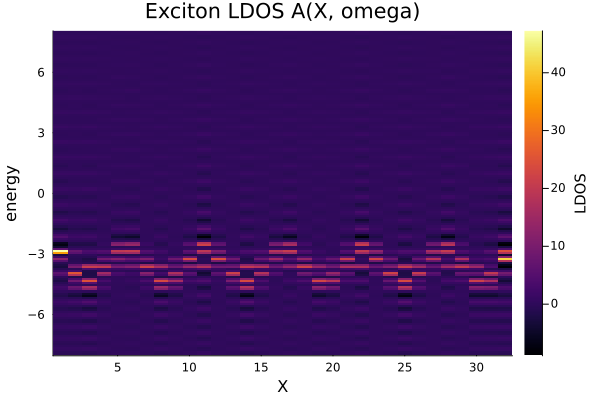

In [20]:
# Exciton LDOS A(X, omega) = <X,X|delta(omega-H)|X,X>
X_list_exc  = collect(1:H_exc.N)
Ncheb_exc   = 80
mdim_exc    = 100
cutoff_exc  = 1e-6
m_order_exc = 6
eta_exc     = 1 / (Ncheb_exc + 1)
omega_exc   = range(-8.0, 8.0; length=160)

ldos_exc_mat = TensorBinding.get_exciton_ldos_spatial(H_exc, Ncheb_exc, omega_exc;
    X_list  = X_list_exc,
    kernel  = :hodc,
    eta     = eta_exc,
    m_order = m_order_exc,
    maxdim  = mdim_exc,
    cutoff  = cutoff_exc)

heatmap(X_list_exc, collect(omega_exc), ldos_exc_mat;
        xlabel="X", ylabel="energy", colorbar_title="LDOS",
        title="Exciton LDOS A(X, omega)", color=:inferno)

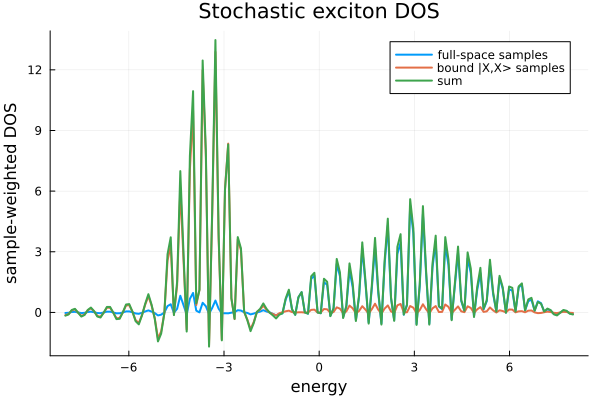

In [ ]:
# Stochastic exciton DOS. The CPU helper supports bound-sector enrichment.
N_sample_exc = 20
N_bound_exc  = 12
seed_exc     = 42

dos_full_exc = TensorBinding.get_dos_stochastic(H_exc, Ncheb_exc, omega_exc;
    N_sample      = N_sample_exc,
    N_bound       = 0,
    seed          = seed_exc,
    kernel        = :hodc,
    eta           = eta_exc,
    m_order       = m_order_exc,
    normalize     = false,
    dos_weighting = :sample,
    maxdim        = mdim_exc,
    cutoff        = cutoff_exc)

dos_bound_exc = TensorBinding.get_dos_stochastic(H_exc, Ncheb_exc, omega_exc;
    N_sample      = 0,
    N_bound       = N_bound_exc,
    seed          = seed_exc + 1,
    kernel        = :hodc,
    eta           = eta_exc,
    m_order       = m_order_exc,
    normalize     = false,
    dos_weighting = :sample,
    maxdim        = mdim_exc,
    cutoff        = cutoff_exc)

dos_total_exc = dos_full_exc .+ dos_bound_exc

plot(collect(omega_exc), [dos_full_exc dos_bound_exc dos_total_exc];
     xlabel="energy", ylabel="sample-weighted DOS",
     title="Stochastic exciton DOS",
     label=["full-space samples" "bound |X,X> samples" "sum"], lw=2)

---
## 2. RPA susceptibility via Wynn ε-algorithm

The Random Phase Approximation resums the Dyson series for the interacting
susceptibility:

$$\chi_\text{RPA} = \Pi_0 + \Pi_0 V \Pi_0 + \Pi_0 V \Pi_0 V \Pi_0 + \cdots
= (I - \Pi_0 V)^{-1} \Pi_0$$

where $\Pi_0(\omega)$ is the non-interacting polarization bubble and $V$ is the
bare interaction.

**Efficient workflow** (two improvements over the raw MPO approach):

1. **Density matrix once** — $P = \theta(\mu - H)$ is computed a single time via
   McWeeny purification and cached in `H._density_cache`.  All frequencies share
   the same $P$; no KPM loop is needed.

2. **Wynn ε-algorithm** — instead of solving the large linear system $(I - \Pi_0 V)\chi = \Pi_0$
   at every $\omega$, we build the Neumann series
   $T_0 = \Pi_0$, $T_n = T_{n-1} V \Pi_0$, extract scalars
   $s_n(q) = -\operatorname{Im}\langle q | T_n | q \rangle / \pi$ via `get_spect_k`,
   and apply the Wynn ε-algorithm to the partial-sum sequence $[S_0, S_1, \ldots, S_K]$
   per $(q, \omega)$.  With $K = 6$ terms, the Padé estimate $\varepsilon_6$ typically
   converges as well as hundreds of MPO solves.

All of this is exposed through the single call `get_rpa_susceptibility_wynn`.

In [22]:
# ── System ────────────────────────────────────────────────────────────────────

L = 5
t = -1.0

H1 = TensorBinding.get_Hamiltonian("chain_1d", t; L=L, scale=scale_exc)

# The density matrix is computed once via McWeeny purification and
# stored in H1._density_cache.  Every call to get_bubble_mpo with
# P_method=:purification will find it there and skip recomputation.

println("Pre-computing P via McWeeny purification...")
TensorBinding.mcweeny_purify(H1; maxiters=40, maxdim=100, cutoff=1e-8, tol=1e-5, verbose=false)
println("Tr(P) = ", real(tr(H1._density_cache)),
        "  (target N/2 = ", H1.N ÷ 2, ")")
println("maxlinkdim(P) = ", ITensorMPS.maxlinkdim(H1._density_cache))

# ── Interaction ───────────────────────────────────────────────────────────────
# On-site Hubbard-U: V(i,j) = U·δ(i,j)  →  MPOV = U × identity MPO
U_hub = 2.0
MPOV  = U_hub * MPO(H1.sites, "Id")
println("\nInteraction: on-site Hubbard U = $U_hub")

Pre-computing P via McWeeny purification...
Tr(P) = 15.99999515968329  (target N/2 = 16)
maxlinkdim(P) = 12

Interaction: on-site Hubbard U = 2.0


In [ ]:
# ── RPA susceptibility via Wynn ε-acceleration ──────────────────────────────
K_max = 6
omegalist_rpa = range(-4.0, 4.0; length=80)

chi_partial, chi_wynn = TensorBinding.get_rpa_susceptibility_wynn(H1, MPOV, omegalist_rpa;
    mode    = :charge,
    K_max   = K_max,
    verbose = false)

n_wynn = K_max ÷ 2
println("chi_partial: ", size(chi_partial), "   chi_wynn: ", size(chi_wynn))

In [ ]:
nq = H1.N
q_axis = 0:nq-1
omega_axis = collect(omegalist_rpa)

# ── Panel 1: Π₀ vs best Wynn estimate ─────────────────────────────────────────
# chi_partial[1,...] = partial sum at K=0, i.e. bare Π₀(q,ω)
# chi_wynn[n_wynn,...] = highest Padé estimate, using K_max+1 terms total
p_pi0 = heatmap(q_axis, omega_axis, chi_partial[1, :, :];
    title="Π₀(q,ω)  [bare bubble]",
    xlabel="q", ylabel="ω", color=:inferno)

p_rpa = heatmap(q_axis, omega_axis, chi_wynn[n_wynn, :, :];
    title="χ_RPA(q,ω)  [Wynn ε_$(2n_wynn), $(K_max+1) terms]",
    xlabel="q", ylabel="ω", color=:inferno)

display(plot(p_pi0, p_rpa; layout=(1, 2), size=(860, 360),
    plot_title="RPA susceptibility  (U = $U_hub, N = $(H1.N))"))

# ── Panel 2: Convergence of partial sums vs Wynn estimates ────────────────────
# Total spectral weight Σ_{q,ω} |−Im χ| at each approximation level
spec_partial = [sum(abs.(chi_partial[k+1, :, :])) for k in 0:K_max]
spec_wynn    = [sum(abs.(chi_wynn[m, :, :]))       for m in 1:n_wynn]

p_conv = plot(0:K_max, spec_partial;
    label="Partial sum K", lw=2, marker=:circle, color=:crimson,
    xlabel="Order K  (number of terms = K+1)",
    ylabel="Σ_{q,ω} |−Im χ|",
    title="Convergence: Neumann series vs Wynn ε-acceleration")

for m in 1:n_wynn
    scatter!(p_conv, [2m], [spec_wynn[m]];
        label="Wynn ε_$(2m)  ($(2m+1) terms)",
        markersize=9, markershape=:star5)
end

hline!(p_conv, [spec_wynn[end]]; lw=1, ls=:dot, color=:gray,
    label="Wynn ε_$(2n_wynn) (best estimate)")

display(plot(p_conv; size=(680, 400)))